# Dummy Problems - Gradient Descent

## Problem 1

For a pendulum acting under gravity and starting at a small deviation angle from down $\theta_0$, the equation of the period is:

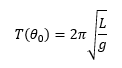

_without rearranging_, use the Gradient Descent algorithm to solve for the pendulum length $L$ given the period $T$ is measured to be 5 seconds (or any arbitrary value).

Check these results against the analytical solution.

### Algorithm 1 - $wx+b$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# GOAL: Use gradient descent algorithm to solve for L given T
# Prediction (y_pred) will be predicted T given prediction of L
# Target value (y) will be measured T

g = 9.81 #m/s^2

def T_theta(L):
    return 2*np.pi * np.sqrt(L/g)

def L_t(T):
    return g * (T / (2*np.pi))**2

#################################
# Gradient Descent Algorithm
#################################
def gradDescent(X, y, w=0.0, b=1.0, lr=0.001, epochs=500):
    loss_history = []

    for i in range(epochs):
        # Prediction of L
        L_pred = w * X + b

        # Prediction T given L
        y_pred = T_theta(L_pred)
        
        # Error function
        error = y_pred - y
        loss = 0.5 * np.mean(error**2)

        # Chain rule
        dT_dL = np.pi / np.sqrt(g*L_pred)

        loss_history.append(loss)
        dw = (1 / len(X)) * np.dot(error * dT_dL, X)
        db = (1 / len(X)) * np.sum(error * dT_dL)

        w -= lr * dw
        b -= lr * db

        if i % 10 == 0:
            print(f"Iteration {i}: Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")


    return w, b, loss, loss_history

### Result

Iteration 0: Loss=52.6985, w=0.1228, b=1.0085
Iteration 10: Loss=26.1598, w=0.5285, b=1.0366
Iteration 20: Loss=20.0840, w=0.7672, b=1.0521
Iteration 30: Loss=16.5765, w=0.9507, b=1.0634
Iteration 40: Loss=14.1987, w=1.1025, b=1.0722
Iteration 50: Loss=12.4543, w=1.2329, b=1.0794
Iteration 60: Loss=11.1119, w=1.3475, b=1.0853
Iteration 70: Loss=10.0446, w=1.4498, b=1.0903
Iteration 80: Loss=9.1759, w=1.5422, b=1.0945
Iteration 90: Loss=8.4560, w=1.6264, b=1.0980
Iteration 100: Loss=7.8508, w=1.7036, b=1.1010
Iteration 110: Loss=7.3362, w=1.7749, b=1.1036
Iteration 120: Loss=6.8945, w=1.8409, b=1.1057
Iteration 130: Loss=6.5123, w=1.9024, b=1.1074
Iteration 140: Loss=6.1792, w=1.9598, b=1.1089
Iteration 150: Loss=5.8873, w=2.0135, b=1.1100
Iteration 160: Loss=5.6302, w=2.0640, b=1.1109
Iteration 170: Loss=5.4026, w=2.1114, b=1.1116
Iteration 180: Loss=5.2003, w=2.1562, b=1.1120
Iteration 190: Loss=5.0199, w=2.1985, b=1.1123
Iteration 200: Loss=4.8585, w=2.2385, b=1.1123
Iteration 210: L

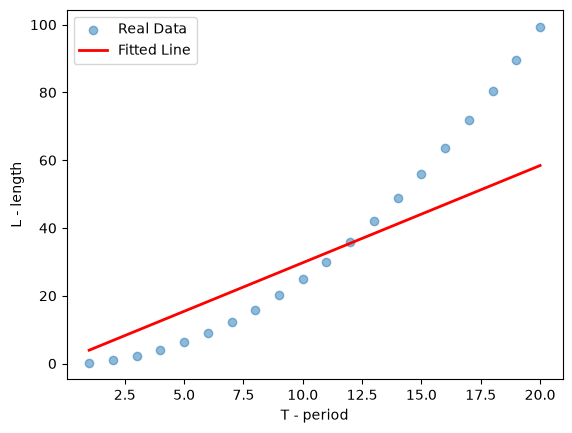

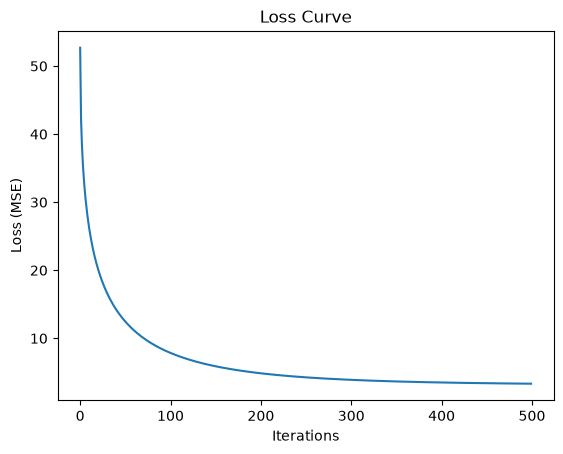

In [2]:
X = np.array(range(1, 21))
y = np.array(range(1, 21))

w, b, loss, loss_history = gradDescent(X, y)

L_true = L_t(X)
L_pred = w * X + b

# Final Model
print("\nFinal Parameters")
print(f"Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

plt.scatter(X, L_true, alpha=0.5, label="Real Data")
plt.plot(X, L_pred,
        color='red', linewidth=2, label="Fitted Line")
plt.xlabel("T - period")
plt.ylabel("L - length")
plt.legend()
plt.show()

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

### Algorithm 2 - $w_1*x^2 + w_2*x + b$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# GOAL: Use gradient descent algorithm to solve for L given T
# Prediction (y_pred) will be predicted T given prediction of L
# Target value (y) will be measured T

def T_theta(L):
    g = 9.81 #m/s^2
    return 2*np.pi * np.sqrt(L/g)

def L_t(T):
    g = 9.81 #m/s^2
    return g * (T / (2*np.pi))**2

#################################
# Gradient Descent Algorithm
#################################
def gradDescent(X, y, w_1=0.0, w_2=0.0, b=1.0, lr=0.001, epochs=100):
    loss_history = []

    for i in range(epochs):
        # Prediction of L
        L_pred = w_1 * X**2 + w_2 * X + b

        # Prediction T given L
        y_pred = T_theta(L_pred)
        
        # Error function
        error = y_pred - y
        loss = 0.5 * np.mean(error**2)

        # Chain rule
        dT_dL = np.pi / np.sqrt(g*L_pred)

        loss_history.append(loss)
        dw_1 = (1 / len(X)) * np.dot(error*dT_dL, X**2)
        dw_2 = (1 / len(X)) * np.dot(error*dT_dL, X)
        db = (1 / len(X)) * np.sum(error)

        w_1 -= lr * dw_1
        w_2 -= lr * dw_2
        b -= lr * db

        if i % 10 == 0:
            print(f"Iteration {i}: Loss={loss:.4f}, w_1={w_1:.4f}, w_2={w_2:.4f}, b={b:.4f}")


    return w_1, w_2, b, loss, loss_history

### Result

Iteration 0: Loss=44.7045, w_1=1.5620, w_2=0.1048, b=1.0075
Iteration 10: Loss=9.3187, w_1=0.3995, w_2=0.0148, b=0.9152
Iteration 20: Loss=0.1555, w_1=0.2424, w_2=0.0008, b=0.9057
Iteration 30: Loss=0.1543, w_1=0.2422, w_2=-0.0014, b=0.9032
Iteration 40: Loss=0.1533, w_1=0.2424, w_2=-0.0036, b=0.9007
Iteration 50: Loss=0.1523, w_1=0.2426, w_2=-0.0057, b=0.8982
Iteration 60: Loss=0.1513, w_1=0.2427, w_2=-0.0078, b=0.8957
Iteration 70: Loss=0.1503, w_1=0.2429, w_2=-0.0100, b=0.8932
Iteration 80: Loss=0.1494, w_1=0.2431, w_2=-0.0121, b=0.8908
Iteration 90: Loss=0.1484, w_1=0.2433, w_2=-0.0141, b=0.8884

Final Parameters
Loss=0.1476, w_1=0.2434, w_2=-0.0160, b=0.8862


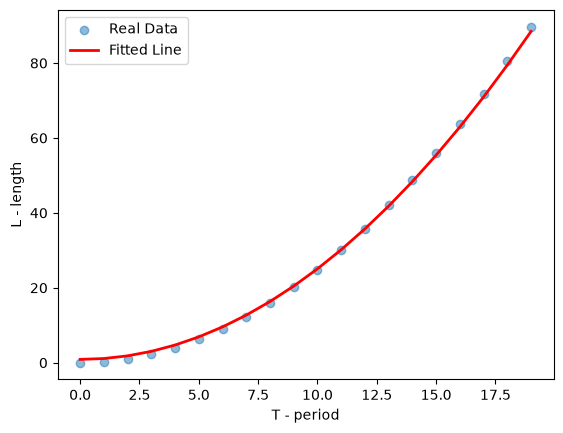

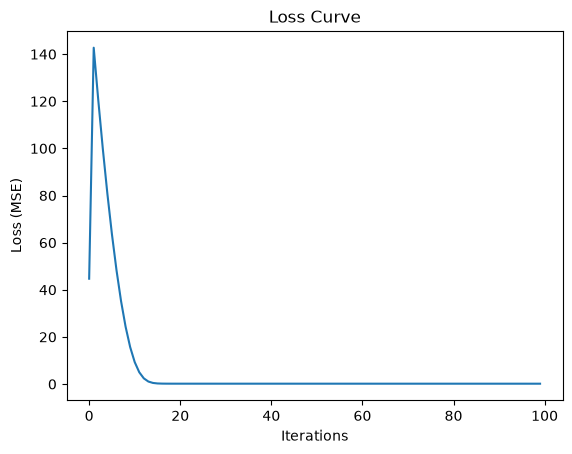

In [4]:
X = np.array(range(20))
y = np.array(range(20))

w_1, w_2, b, loss, loss_history = gradDescent(X, y)

L_true = L_t(X)
L_pred = w_1 * X**2 + w_2 * X + b

# Final Model
print("\nFinal Parameters")
print(f"Loss={loss:.4f}, w_1={w_1:.4f}, w_2={w_2:.4f}, b={b:.4f}")

plt.scatter(X, L_true, alpha=0.5, label="Real Data")
plt.plot(X, L_pred,
        color='red', linewidth=2, label="Fitted Line")
plt.xlabel("T - period")
plt.ylabel("L - length")
plt.legend()
plt.show()

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

## Problem 2
For a pendulum acting under gravity and starting at an arbitrarily large deviation angle from down $\theta_0$, the equation of the period is:

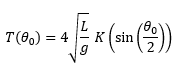

where $K$ is the complete elliptic integral of the first kind ([Elliptic integral - Wikipedia](https://en.wikipedia.org/wiki/Elliptic_integral#Complete_elliptic_integral_of_the_first_kind "https://en.wikipedia.org/wiki/Elliptic_integral#Complete_elliptic_integral_of_the_first_kind")). Use the gradient descent algorithm to solve for $\theta_0$ when the length $L$ = 2.6 m  and the period $T$ is measured to be 5 seconds (or any arbitrary values).

### Algorithm - Predicts one value

In [24]:
# GOAL: Use gradient descent algorithm to solve for theta given T and L
# Prediction (y_pred) will be predicted T given prediction of theta
# Target value (y) will be measured T

from scipy.special import ellipk, ellipe

g = 9.81 #m/s^2

def T_theta(theta, L=2.6):
    k = np.sin(theta / 2)
    K = ellipk(k**2)
    return 4* np.sqrt(L/g) * K

def dT_dtheta(theta, L=2.6):
    dk_dtheta = 1/2 * np.cos(theta/2)

    k = np.sin(theta/2)
    K = ellipk(k**2)
    E = ellipe(k**2)

    dK_dk = E/(k*(1-k**2)) - K/k

    return 4 * np.sqrt(L/g) * dK_dk * dk_dtheta


#################################
# Gradient Descent Algorithm
# TODO : Re do this section
#################################
def gradDescent(T_measured, L=2.6, theta=0.1, lr=0.02, epochs=500):
    loss_history = []

    for i in range(epochs):
        # Prediction of T given current theta
        T_pred = T_theta(theta, L)
        
        # Error function
        error = T_pred - T_measured
        loss = 0.5 * np.mean(error**2)
        loss_history.append(loss)

        # Chain rule
        dE_dtheta = error * dT_dtheta(theta)

        theta -= lr * dE_dtheta

        if i % 20 == 0:
            print(f"Iteration {i}: Loss={loss:.6f}, theta={theta:.4f}")


    return theta, loss, loss_history

### Result

Iteration 0: Loss=1.554599, theta=0.1014
Iteration 20: Loss=1.551876, theta=0.1347
Iteration 40: Loss=1.547076, theta=0.1788
Iteration 60: Loss=1.538614, theta=0.2374
Iteration 80: Loss=1.523696, theta=0.3152
Iteration 100: Loss=1.497404, theta=0.4185
Iteration 120: Loss=1.451090, theta=0.5556
Iteration 140: Loss=1.369655, theta=0.7374
Iteration 160: Loss=1.227341, theta=0.9777
Iteration 180: Loss=0.983942, theta=1.2919
Iteration 200: Loss=0.600609, theta=1.6856
Iteration 220: Loss=0.169226, theta=2.0984
Iteration 240: Loss=0.008032, theta=2.3310
Iteration 260: Loss=0.000089, theta=2.3758
Iteration 280: Loss=0.000001, theta=2.3803
Iteration 300: Loss=0.000000, theta=2.3807
Iteration 320: Loss=0.000000, theta=2.3808
Iteration 340: Loss=0.000000, theta=2.3808
Iteration 360: Loss=0.000000, theta=2.3808
Iteration 380: Loss=0.000000, theta=2.3808
Iteration 400: Loss=0.000000, theta=2.3808
Iteration 420: Loss=0.000000, theta=2.3808
Iteration 440: Loss=0.000000, theta=2.3808
Iteration 460: Lo

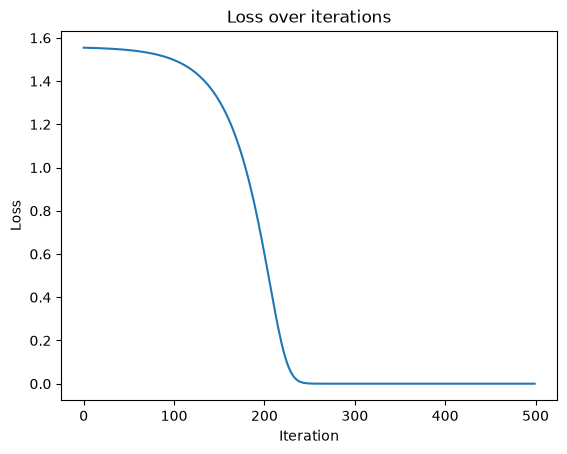

In [25]:
T_true = 5

theta_final, loss, loss_history = gradDescent(T_true)

T_pred = w * X + b

# Final Model
print("\nFinal Parameters")
print(f"Loss={loss:.4f}, theta= {theta_final:.4f} rad ({np.degrees(theta_final):.2f} deg)")

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over iterations")
plt.show()